# Tari'ak Traffic Analysis, 01 — SQL Traffic Analysis

This notebook begins the SQL analysis of the cleaned Tari'ak traffic observations. The first questions focus on the reliability of the SQLite import, broad hourly patterns, and differences between mapped road segments. The purpose is to understand the structure of the observed movement data before grouping segments into recurring mobility patterns.

The analysis describes recorded observations. A low observed velocity is not treated as proof of congestion without considering observation volume, road context, and the limitations of the source data.

## 1. Load the processed data into SQLite

The cleaned CSV contains more than six million rows, so it is loaded into SQLite in chunks. The resulting local database allows the remaining analysis to use SQL without repeatedly loading the full CSV into a Pandas dataframe.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd

BASE_DIR = Path('..')
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_FILE = PROCESSED_DIR / 'traffic_clean.csv'
DB_PATH = PROCESSED_DIR / 'traffic.db'
TABLE_NAME = 'traffic_observations'
CHUNK_SIZE = 250_000

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

def run_query(query):
    return pd.read_sql_query(query, conn)

print(f'Processed CSV exists: {PROCESSED_FILE.exists()}')
print(f'Processed CSV size: {PROCESSED_FILE.stat().st_size / 1024**2:,.1f} MB')

Processed CSV exists: True
Processed CSV size: 581.5 MB


In [2]:
REBUILD_DATABASE = False
if not DB_PATH.exists():
    REBUILD_DATABASE = True

conn = sqlite3.connect(DB_PATH)

if REBUILD_DATABASE:
    for chunk_number, chunk in enumerate(pd.read_csv(PROCESSED_FILE, chunksize=CHUNK_SIZE), start=1):
        chunk.to_sql(
            TABLE_NAME,
            conn,
            if_exists='replace' if chunk_number == 1 else 'append',
            index=False
        )

        if chunk_number % 10 == 0:
            print(f'Loaded {chunk_number * CHUNK_SIZE:,} rows...')

    conn.execute(f'CREATE INDEX IF NOT EXISTS idx_{TABLE_NAME}_timestamp ON {TABLE_NAME} (timestamp)')
    conn.execute(f'CREATE INDEX IF NOT EXISTS idx_{TABLE_NAME}_osm_id ON {TABLE_NAME} (osm_id)')
    conn.execute(f'CREATE INDEX IF NOT EXISTS idx_{TABLE_NAME}_hour ON {TABLE_NAME} (hour)')
    conn.commit()

print(f'Connected to: {DB_PATH}')
print(f'Active table: {TABLE_NAME}')

Connected to: ..\data\processed\traffic.db
Active table: traffic_observations


## 2. Verify the Processed Table

Before writing grouped analyses, I verify that the SQLite table contains the same observation count and time boundaries established in Notebook 00. This confirms that the processed CSV was loaded without changing the row grain or dropping observations.

The query below checks the total number of observations and the temporal boundaries of the table.

In [3]:
table_summary_query = """
SELECT
    COUNT(*) AS total_row_count,
    MIN(timestamp) AS min_timestamp,
    MAX(timestamp) AS max_timestamp
FROM traffic_observations;
"""

table_summary = run_query(table_summary_query)
display(table_summary)

,total_row_count,min_timestamp,max_timestamp
0,6006401,2015-03-20 00:00:48,2019-10-17 23:58:41


The SQLite table contains 6,006,401 observations, covering March 20, 2015 through October 17, 2019. This matches the feasibility notebook, so the processed data was loaded without changing the row count or temporal boundaries.

With the import verified, I can examine whether the observed velocity distribution changes across the day.

## 3. Hourly Velocity Patterns

The first descriptive question is whether recorded velocity changes across the day. I group the observations by the engineered `hour` field and keep the observation count alongside the average so that the averages can be interpreted together with the amount of data behind them.

In [4]:
hourly_profile_query = """
SELECT
    hour,
    COUNT(*) AS total_row_count,
    ROUND(AVG(velocity), 2) AS average_velocity
FROM traffic_observations
GROUP BY hour
ORDER BY hour ASC;
"""

hourly_profile = run_query(hourly_profile_query)
display(hourly_profile)

,hour,total_row_count,average_velocity
0,0,124631,54.780
1,1,69851,55.790
2,2,35278,57.450
3,3,20996,59.740
4,4,18055,59.880
5,5,27589,60.260
6,6,114915,55.460
7,7,236684,43.910
8,8,297399,44.220
9,9,335471,44.190


Observed velocity varies by hour. In this dataset, the highest hourly average is approximately 60.26 at 05:00, while the lowest is approximately 41.26 at 17:00. Observation volume also changes substantially by hour, so these results describe the recorded sample rather than proving that congestion causes the difference.

The hourly result may partly reflect which roads are represented at different times. The next analysis therefore moves from the overall time pattern to road-segment profiles.

## 4. Road-Segment Profiles

The dataset contains repeated observations for 14,289 mapped street identifiers. I will group by `osm_id` and compare observation count, average velocity, minimum velocity, and maximum velocity. Sorting by observation count first will show which segments have enough data to support interpretation.

In [5]:
segment_profile_query = """
SELECT
    osm_id,
    COUNT(*) AS total_row_count,
    ROUND(AVG(velocity), 2) AS average_velocity,
    ROUND(MIN(velocity), 2) AS minimum_velocity,
    ROUND(MAX(velocity), 2) AS maximum_velocity
FROM traffic_observations
GROUP BY osm_id
ORDER BY total_row_count DESC
LIMIT 20;
"""

segment_profile = run_query(segment_profile_query)
display(segment_profile)

,osm_id,total_row_count,average_velocity,minimum_velocity,maximum_velocity
0,way/212368273,66223,64.670,0.000,119.990
1,way/26547512,64944,40.500,0.000,120.000
2,way/197464561,49989,81.580,0.000,119.990
3,way/212368259,47078,41.980,0.000,119.790
4,way/269505955,43174,66.450,0.000,119.980
5,way/200723968,41170,45.040,0.000,119.830
6,way/251916592,38432,82.370,0.000,119.990
7,way/26547446,36490,59.360,0.000,119.950
8,way/251916594,35199,45.380,0.000,119.990
9,way/26586371,34445,45.630,0.000,118.940


The road-segment profile shows that the dataset is unevenly distributed across mapped streets. The most frequently observed segment has 66,223 records, while the average observed velocity differs substantially between highly sampled segments.

The minimum and maximum values are less informative at this stage: nearly every segment reaches values close to the global lower and upper bounds. This means that ranking segments by average velocity and observation count will be more useful than interpreting isolated minimum or maximum values.

The next analysis will filter out poorly observed segments and identify the lowest-average-velocity segments as candidates for further investigation. These candidates still require temporal analysis before they can be described as recurring bottlenecks.

## 5. Absolute Velocity Screening

After profiling the segments, I will apply a minimum observation threshold and rank segments by observed velocity. This is only an initial screening step. A low absolute velocity may simply reflect a local road, a ramp, a turn, or another road characteristic, so these results cannot be called confirmed congestion hotspots without additional context.

In [6]:
low_velocity_segments_query = """
SELECT
    osm_id,
    COUNT(*) AS total_row_count,
    ROUND(AVG(velocity), 2) AS average_velocity,
    ROUND(MIN(velocity), 2) AS minimum_velocity,
    ROUND(MAX(velocity), 2) AS maximum_velocity
FROM traffic_observations
GROUP BY osm_id
HAVING COUNT(*) >= 5000
ORDER BY AVG(velocity) ASC
LIMIT 20;
"""

low_velocity_segments = run_query(low_velocity_segments_query)
display(low_velocity_segments)

,osm_id,total_row_count,average_velocity,minimum_velocity,maximum_velocity
0,way/200761261,5220,18.770,0.000,98.840
1,way/26491370,5359,18.830,0.000,95.750
2,way/25915725,6050,19.190,0.000,107.570
3,way/33691469,10849,23.640,0.000,114.990
4,way/205362956,8140,25.190,0.000,109.650
5,way/26757004,7615,25.360,0.000,93.050
6,way/200761173,5630,26.650,0.000,100.570
7,way/26796491,7979,26.820,0.000,98.160
8,way/205362938,13416,27.030,0.000,116.820
9,way/261104483,9687,27.370,0.010,119.700


The lowest-average segments in this screening range from roughly 18.77 to 31.01 meters per second. These values should not automatically be described as slow: without road class, speed limit, or traffic-volume data, a lower average may reflect the normal design or function of a particular street.

The result also reinforces that minimum and maximum velocity are poor standalone indicators. Several segments have values close to both zero and the dataset-wide upper bound. The stronger next question is whether a segment becomes slower than its own normal level at particular hours, rather than whether it has the lowest absolute average in the country.

## 6. Relative Segment Slowdowns

Absolute velocity is difficult to interpret without road type or speed-limit information. I therefore compare each segment-hour average with that segment's overall baseline. A negative difference means the segment is slower than its own typical observed level during that hour.

In [7]:
relative_slowdown_query = """
WITH segment_baseline AS (
    SELECT
        osm_id,
        AVG(velocity) AS baseline_velocity
    FROM traffic_observations
    GROUP BY osm_id
),
segment_hourly AS (
    SELECT
        osm_id,
        hour,
        COUNT(*) AS observation_count,
        AVG(velocity) AS hourly_velocity
    FROM traffic_observations
    GROUP BY osm_id, hour
    HAVING COUNT(*) >= 100
)
SELECT
    sh.osm_id,
    sh.hour,
    sh.observation_count,
    ROUND(sh.hourly_velocity, 2) AS hourly_velocity,
    ROUND(sb.baseline_velocity, 2) AS baseline_velocity,
    ROUND(sh.hourly_velocity - sb.baseline_velocity, 2) AS velocity_difference
FROM segment_hourly AS sh
JOIN segment_baseline AS sb
    ON sh.osm_id = sb.osm_id
ORDER BY sh.hourly_velocity - sb.baseline_velocity ASC
LIMIT 50;
"""

relative_slowdowns = run_query(relative_slowdown_query)
display(relative_slowdowns)

,osm_id,hour,observation_count,hourly_velocity,baseline_velocity,velocity_difference
0,way/237739169,7,118,7.340,36.250,-28.910
1,way/261184507,17,176,27.350,52.950,-25.600
2,way/5051935,7,184,17.440,42.940,-25.500
3,way/26547451,7,1244,21.170,46.190,-25.020
4,way/30733074,7,157,40.710,65.430,-24.710
5,way/44583778,7,208,30.130,54.710,-24.580
6,way/262830287,7,724,18.310,42.600,-24.290
7,way/200771266,8,102,23.410,47.630,-24.210
8,way/530758642,17,256,23.470,47.500,-24.030
9,way/200726458,12,137,24.870,48.700,-23.830


The largest negative differences appear mainly around hours 7, 8, 17, and 18. `way/26547451` is especially notable: it appears on 68 dates at hour 7 and has an average daily velocity of 11.95 compared with a segment baseline of 46.19. Other segments also recur across 30 or more dates with negative differences.

This is stronger evidence of a repeated segment-hour pattern than the earlier absolute-speed ranking, but it is still not proof of congestion. The query took approximately 76 seconds because it repeatedly groups millions of raw observations. It also compares an observation-weighted segment baseline with an average of daily segment-hour averages. The next step should materialize a daily segment-hour summary once, then reuse it for faster and more consistent analysis.

## 7. Recurring Daily Slowdowns

The previous comparison grouped all observations directly by segment and hour. To test whether a pattern recurs across different dates, I first calculate a daily average for each segment-hour, then summarize those daily averages. This gives each date equal weight instead of allowing dates with more observations to dominate the result.

In [8]:
daily_relative_slowdown_query = """
WITH daily_segment_hour AS (
    SELECT
        osm_id,
        DATE(timestamp) AS observation_date,
        hour,
        COUNT(*) AS daily_observation_count,
        AVG(velocity) AS daily_average_velocity
    FROM traffic_observations
    GROUP BY osm_id, observation_date, hour
    HAVING COUNT(*) >= 5
),
segment_baseline AS (
    SELECT
        osm_id,
        AVG(velocity) AS baseline_velocity
    FROM traffic_observations
    GROUP BY osm_id
),
recurring_slowdowns AS (
    SELECT
        osm_id,
        hour,
        COUNT(*) AS observed_days,
        SUM(daily_observation_count) AS total_observations,
        AVG(daily_average_velocity) AS average_daily_velocity,
        MIN(daily_average_velocity) AS minimum_daily_velocity,
        MAX(daily_average_velocity) AS maximum_daily_velocity,
        AVG(daily_average_velocity * daily_average_velocity) -
            AVG(daily_average_velocity) * AVG(daily_average_velocity)
            AS daily_velocity_variance
    FROM daily_segment_hour
    GROUP BY osm_id, hour
    HAVING COUNT(*) >= 5
)
SELECT
    rs.osm_id,
    rs.hour,
    rs.observed_days,
    rs.total_observations,
    ROUND(rs.average_daily_velocity, 2) AS average_daily_velocity,
    ROUND(sb.baseline_velocity, 2) AS baseline_velocity,
    ROUND(rs.average_daily_velocity - sb.baseline_velocity, 2)
        AS velocity_difference,
    ROUND(MAX(rs.daily_velocity_variance, 0), 2)
        AS daily_velocity_variance,
    ROUND(rs.maximum_daily_velocity, 2) AS maximum_daily_velocity
FROM recurring_slowdowns AS rs
JOIN segment_baseline AS sb
    ON rs.osm_id = sb.osm_id
ORDER BY velocity_difference ASC
LIMIT 50;
"""

daily_relative_slowdowns = run_query(daily_relative_slowdown_query)
daily_relative_slowdowns['daily_velocity_std'] = (
    daily_relative_slowdowns['daily_velocity_variance'].clip(lower=0) ** 0.5
).round(2)
daily_relative_slowdowns = daily_relative_slowdowns.drop(
    columns='daily_velocity_variance'
)
display(daily_relative_slowdowns)

,osm_id,hour,observed_days,total_observations,average_daily_velocity,baseline_velocity,velocity_difference,maximum_daily_velocity,daily_velocity_std
0,way/32040176,17,7,43,15.680,74.660,-58.980,28.550,8.330
1,way/200761150,10,12,81,14.780,70.540,-55.760,45.780,11.040
2,way/32040176,11,8,46,19.490,74.660,-55.170,40.650,11.820
3,way/584853983,7,6,38,7.460,60.100,-52.640,16.070,4.450
4,way/32040176,15,8,59,23.040,74.660,-51.610,55.070,16.450
5,way/200761150,9,13,83,22.320,70.540,-48.220,76.000,24.330
6,way/23901698,20,5,28,31.220,78.520,-47.300,76.400,23.930
7,way/26547436,12,8,44,16.490,63.430,-46.940,35.040,9.500
8,way/227003588,17,5,27,19.910,66.340,-46.430,32.430,6.590
9,way/26547436,13,12,72,17.490,63.430,-45.940,57.660,13.150


The strongest recurring differences are concentrated around the morning and evening commuting hours. For example, `way/26547451` at hour 7 appears across 68 dates, with an average daily velocity of 11.95 compared with a segment baseline of 46.19. Its negative difference is therefore recurring across dates, not just caused by one unusually slow observation.

The daily standard deviation helps separate consistently slow segment-hours from patterns that are highly unstable. These results are still candidate mobility bottlenecks rather than confirmed congestion, because the dataset does not include traffic volume, road capacity, speed limits, incidents, or vehicle trajectories.

## 8. Materializing the Daily Summary

The previous query rebuilt the daily segment-hour grain every time it ran. I now save that intermediate result as a SQLite table. This lets later analyses reuse the same daily summary instead of repeatedly scanning and regrouping the full observations table.

In [9]:
conn.execute("""
DROP TABLE IF EXISTS daily_segment_hour;
""")

conn.execute("""
CREATE TABLE daily_segment_hour AS
SELECT
    osm_id,
    DATE(timestamp) AS observation_date,
    hour,
    COUNT(*) AS daily_observation_count,
    AVG(velocity) AS daily_average_velocity
FROM traffic_observations
GROUP BY osm_id, observation_date, hour
HAVING COUNT(*) >= 5;
""")
conn.commit()

In [10]:
conn.execute("""
CREATE INDEX IF NOT EXISTS idx_daily_segment_hour
ON daily_segment_hour (osm_id, hour);
""")
conn.commit()

The verification query checks the size and coverage of the new summary table before it becomes the source for the remaining analyses.

In [11]:
daily_summary_check = run_query("""
SELECT
    COUNT(*) AS summary_rows,
    COUNT(DISTINCT osm_id) AS segments,
    MIN(observation_date) AS first_date,
    MAX(observation_date) AS last_date
FROM daily_segment_hour;
""")
display(daily_summary_check)

,summary_rows,segments,first_date,last_date
0,83980,2320,2015-03-20,2019-10-17


The summary table is now the reusable daily observation grain for the next analyses. The `HAVING COUNT(*) >= 5` condition excludes segment-hours supported by only a handful of raw records, reducing the influence of extremely sparse groups.

## 9. Weekday and Weekend Segment Patterns

A candidate slowdown is more useful when its time pattern changes in a way that is consistent with normal travel demand. This comparison matches the same road segment and hour across weekdays and weekends. It only retains combinations observed on at least 10 dates of each type, so the two averages are supported by repeated dates rather than isolated records.

In [12]:
weekday_weekend_query = """
WITH daily_by_type AS (
    SELECT
        osm_id,
        hour,
        CASE
            WHEN STRFTIME('%w', observation_date) IN ('0', '6')
                THEN 'weekend'
            ELSE 'weekday'
        END AS day_type,
        COUNT(*) AS observed_days,
        AVG(daily_average_velocity) AS average_daily_velocity
    FROM daily_segment_hour
    GROUP BY osm_id, hour, day_type
    HAVING COUNT(*) >= 10
),
matched_profiles AS (
    SELECT
        weekday.osm_id,
        weekday.hour,
        weekday.observed_days AS weekday_days,
        weekend.observed_days AS weekend_days,
        weekday.average_daily_velocity AS weekday_velocity,
        weekend.average_daily_velocity AS weekend_velocity
    FROM daily_by_type AS weekday
    JOIN daily_by_type AS weekend
        ON weekday.osm_id = weekend.osm_id
        AND weekday.hour = weekend.hour
    WHERE weekday.day_type = 'weekday'
        AND weekend.day_type = 'weekend'
)
SELECT
    osm_id,
    hour,
    weekday_days,
    weekend_days,
    ROUND(weekday_velocity, 2) AS weekday_velocity,
    ROUND(weekend_velocity, 2) AS weekend_velocity,
    ROUND(weekday_velocity - weekend_velocity, 2)
        AS weekday_minus_weekend
FROM matched_profiles
ORDER BY weekday_velocity - weekend_velocity ASC
LIMIT 30;
"""

weekday_weekend_profiles = run_query(weekday_weekend_query)
display(weekday_weekend_profiles)

,osm_id,hour,weekday_days,weekend_days,weekday_velocity,weekend_velocity,weekday_minus_weekend
0,way/212368259,18,229,36,24.830,54.860,-30.030
1,way/212368273,7,255,17,47.770,76.930,-29.160
2,way/212368259,17,172,28,22.000,50.440,-28.440
3,way/26547512,8,302,15,26.370,54.690,-28.320
4,way/26547512,9,376,29,26.460,54.460,-28.000
5,way/212368273,8,252,18,53.600,79.100,-25.500
6,way/251916594,11,72,15,33.580,58.780,-25.200
7,way/200727720,18,53,12,19.060,43.400,-24.340
8,way/200727720,16,41,10,24.030,48.060,-24.030
9,way/26547512,10,312,37,28.840,52.750,-23.910


A negative `weekday_minus_weekend` value means the same segment-hour is slower on weekdays. The clearest result is `way/212368259` at hour 18: its average daily velocity is 24.83 across 229 weekday dates, compared with 54.86 across 36 weekend dates, a difference of -30.03. Other large weekday deficits appear for `way/212368273` at hours 7 and 8 and for `way/26547512` at hours 8 and 9.

This pattern is compatible with commuting-related movement, but it remains descriptive evidence. Weekday and weekend sample sizes are often unequal, and changing route mix, sampling behavior, or other unobserved conditions may contribute to the difference.

## 10. Candidate Mobility-Bottleneck Ranking

The final SQL ranking combines the evidence built so far. It compares each segment-hour with the segment's own daily baseline, requires at least 30 observed dates and 200 raw observations, then ranks by percentage slowdown. The result is a shortlist for later mapping and clustering, not a claim that the listed roads are confirmed congestion hotspots.

In [13]:
candidate_ranking_query = """
WITH segment_baseline AS (
    SELECT
        osm_id,
        AVG(daily_average_velocity) AS baseline_velocity
    FROM daily_segment_hour
    GROUP BY osm_id
),
segment_hour_profile AS (
    SELECT
        osm_id,
        hour,
        COUNT(*) AS observed_days,
        SUM(daily_observation_count) AS total_observations,
        AVG(daily_average_velocity) AS average_daily_velocity,
        AVG(daily_average_velocity * daily_average_velocity) -
            AVG(daily_average_velocity) * AVG(daily_average_velocity)
            AS daily_velocity_variance
    FROM daily_segment_hour
    GROUP BY osm_id, hour
    HAVING COUNT(*) >= 30
        AND SUM(daily_observation_count) >= 200
)
SELECT
    shp.osm_id,
    shp.hour,
    shp.observed_days,
    shp.total_observations,
    ROUND(shp.average_daily_velocity, 2) AS average_daily_velocity,
    ROUND(sb.baseline_velocity, 2) AS baseline_velocity,
    ROUND(sb.baseline_velocity - shp.average_daily_velocity, 2)
        AS velocity_drop,
    ROUND(
        100.0 * (sb.baseline_velocity - shp.average_daily_velocity)
        / sb.baseline_velocity,
        2
    ) AS slowdown_percentage,
    ROUND(MAX(shp.daily_velocity_variance, 0), 2)
        AS daily_velocity_variance
FROM segment_hour_profile AS shp
JOIN segment_baseline AS sb
    ON shp.osm_id = sb.osm_id
WHERE shp.average_daily_velocity < sb.baseline_velocity
    AND sb.baseline_velocity > 0
ORDER BY slowdown_percentage DESC, observed_days DESC
LIMIT 30;
"""

candidate_bottlenecks = run_query(candidate_ranking_query)
candidate_bottlenecks['daily_velocity_std'] = (
    candidate_bottlenecks['daily_velocity_variance'].clip(lower=0) ** 0.5
).round(2)
candidate_bottlenecks = candidate_bottlenecks.drop(
    columns='daily_velocity_variance'
)
display(candidate_bottlenecks)

,osm_id,hour,observed_days,total_observations,average_daily_velocity,baseline_velocity,velocity_drop,slowdown_percentage,daily_velocity_std
0,way/205362956,7,93,641,12.350,20.510,8.160,39.790,5.880
1,way/26547451,7,68,456,11.950,19.520,7.570,38.770,9.380
2,way/237737315,7,36,218,17.560,28.370,10.810,38.090,10.130
3,way/42805783,18,31,201,12.870,19.380,6.510,33.600,8.170
4,way/212368259,14,199,1566,24.080,35.180,11.100,31.540,15.380
5,way/5051946,7,33,209,6.210,8.980,2.770,30.840,3.810
6,way/26547451,12,34,211,13.540,19.520,5.980,30.620,8.240
7,way/212368259,15,190,1549,25.110,35.180,10.070,28.620,16.400
8,way/212368259,17,200,1540,25.980,35.180,9.200,26.150,15.340
9,way/212368259,13,200,1504,26.860,35.180,8.320,23.650,15.900


The shortlist favors recurrent relative slowdowns over low raw velocity alone. `way/205362956` at hour 7 has the largest ranked slowdown: 12.35 compared with a 20.51 baseline, a drop of 39.79% across 93 dates and 641 raw observations. `way/26547451` at hour 7 is close behind, with a 38.77% drop across 68 dates and 456 observations.

The strongest percentage drops are not automatically the strongest practical candidates. For example, `way/26547512` at hours 8 and 9 has more extensive support—317 and 405 observed dates, respectively—while still showing slowdowns of 21.40% and 19.27%. `observed_days` and `total_observations` therefore need to be read alongside the slowdown percentage, and `daily_velocity_std` indicates whether the daily values are relatively stable or highly variable. The next notebook will use these time-of-day profiles as features for clustering; it will not treat this ranking as ground-truth congestion labels.

## 11. Segment Features for Clustering

The analyses above established recurring segment-hour patterns and a candidate bottleneck ranking. Before clustering in Notebook 02, I need to produce a compact feature table: one row per sufficiently-observed road segment, with columns that capture each segment's overall velocity behavior, rush-hour sensitivity, and observation reliability.

**Zero-velocity decision (from Notebook 00):** Zero and near-zero (< 0.1 m/s) observations are excluded from velocity-based feature calculations (median velocity, standard deviation, relative slowdowns) because their cause is ambiguous — they may represent stationary vehicles, GPS artifacts, or measurement edge cases. The count of zero/near-zero observations is preserved as a separate diagnostic field (`zero_velocity_observation_count`) so the information is not lost.

**AM/PM hour ranges:** AM peak is defined as hours 7–9 and PM peak as hours 17–19, based on the hourly patterns established in Sections 3 and 6–7 above (strongest slowdowns concentrated at hours 7, 8, 17, 18).

### 11.1 Observation coverage and threshold selection

Before filtering, I examine how observation count and active days are distributed across the 14,289 segments. The threshold should be chosen from the data's shape rather than asserted.

Total segments: 14,289

Observation count distribution:


,observation_count
count,"14,289.000"
mean,420.351
std,"1,959.996"
min,1.000
25%,6.000
50%,35.000
75%,185.000
max,"66,223.000"



Active days distribution:


,active_days
count,"14,289.000"
mean,151.348
std,281.046
min,1.000
25%,6.000
50%,31.000
75%,148.000
max,"1,672.000"


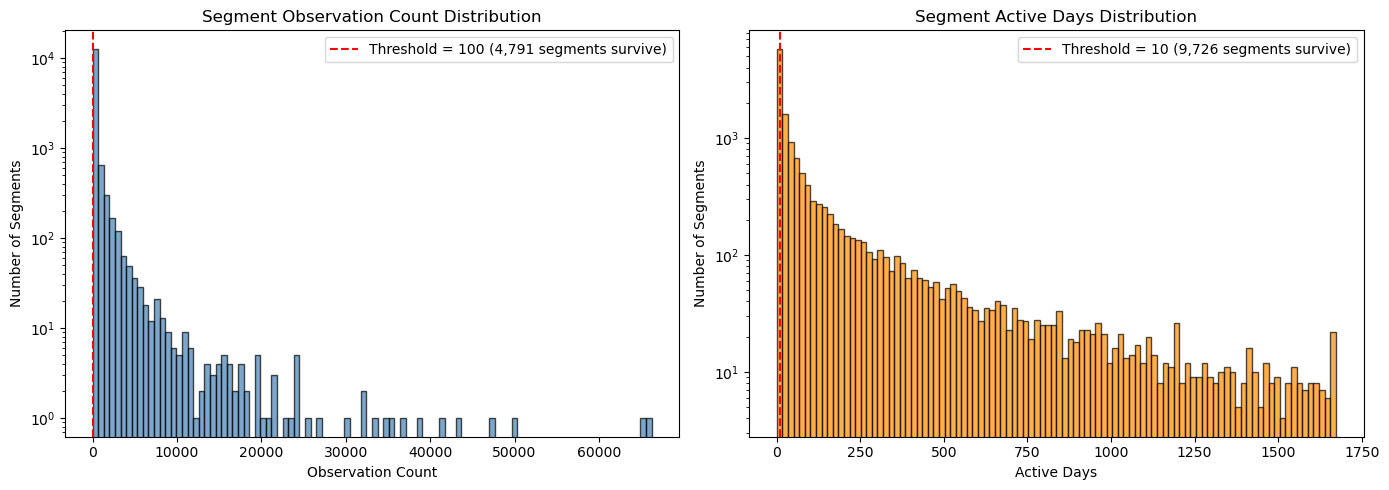


Segments surviving combined threshold (>=100 obs AND >=10 active days): 4,791 of 14,289 (33.5%)

Threshold sensitivity:


,min_observations,min_active_days,surviving_segments,pct_of_total
0,50,5,6343,44.400
1,50,10,6343,44.400
2,50,20,6338,44.400
3,50,30,6310,44.200
4,100,5,4791,33.500
5,100,10,4791,33.500
6,100,20,4790,33.500
7,100,30,4786,33.500
8,200,5,3424,24.000
9,200,10,3424,24.000


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# --- Per-segment observation count and active days ---
segment_coverage = run_query("""
SELECT
    osm_id,
    COUNT(*) AS observation_count,
    COUNT(DISTINCT DATE(timestamp)) AS active_days
FROM traffic_observations
GROUP BY osm_id
""")

print(f'Total segments: {len(segment_coverage):,}')
print(f'\nObservation count distribution:')
display(segment_coverage['observation_count'].describe().to_frame())
print(f'\nActive days distribution:')
display(segment_coverage['active_days'].describe().to_frame())

# --- Histogram of observation count (log scale) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(segment_coverage['observation_count'], bins=100, edgecolor='black',
             alpha=0.7, color='steelblue')
axes[0].set_xlabel('Observation Count')
axes[0].set_ylabel('Number of Segments')
axes[0].set_title('Segment Observation Count Distribution')
axes[0].set_yscale('log')
axes[0].axvline(x=100, color='red', linestyle='--', linewidth=1.5,
                label=f'Threshold = 100 ({(segment_coverage["observation_count"] >= 100).sum():,} segments survive)')
axes[0].legend()

axes[1].hist(segment_coverage['active_days'], bins=100, edgecolor='black',
             alpha=0.7, color='darkorange')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Number of Segments')
axes[1].set_title('Segment Active Days Distribution')
axes[1].set_yscale('log')
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=1.5,
                label=f'Threshold = 10 ({(segment_coverage["active_days"] >= 10).sum():,} segments survive)')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Combined threshold survival ---
combined_mask = (
    (segment_coverage['observation_count'] >= 100) &
    (segment_coverage['active_days'] >= 10)
)
print(f'\nSegments surviving combined threshold (>=100 obs AND >=10 active days): '
      f'{combined_mask.sum():,} of {len(segment_coverage):,} '
      f'({combined_mask.sum() / len(segment_coverage) * 100:.1f}%)')

# Show the filtering at a few candidate thresholds for context
threshold_table = []
for obs_thresh in [50, 100, 200, 500]:
    for day_thresh in [5, 10, 20, 30]:
        surviving = (
            (segment_coverage['observation_count'] >= obs_thresh) &
            (segment_coverage['active_days'] >= day_thresh)
        ).sum()
        threshold_table.append({
            'min_observations': obs_thresh,
            'min_active_days': day_thresh,
            'surviving_segments': surviving,
            'pct_of_total': round(100.0 * surviving / len(segment_coverage), 1)
        })

print('\nThreshold sensitivity:')
display(pd.DataFrame(threshold_table))

### Threshold selection

The histograms above show the distribution shape. The combined threshold of ≥100 observations AND ≥10 active days is applied below. The threshold table confirms how many segments survive at different cutoff combinations. The goal is to exclude segments with too little data to support a meaningful behavioral profile, without discarding the bulk of usable segments.

In [15]:
# =================================================================
# Build segment_features: one row per sufficiently-observed segment
# =================================================================

MIN_OBSERVATIONS = 100
MIN_ACTIVE_DAYS = 10
AM_HOURS = (7, 8, 9)
PM_HOURS = (17, 18, 19)

# --- 1. Per-segment velocity stats (excluding velocity < 0.1 m/s) ---
# Pull osm_id + velocity for moving rows, compute median/std in Pandas.
# Two columns across ~6M rows is manageable in memory.

print('Loading per-segment velocity data (excluding near-zero < 0.1 m/s)...')
seg_velocity_raw = run_query("""
SELECT osm_id, velocity
FROM traffic_observations
WHERE velocity >= 0.1
""")
print(f'Moving velocity rows loaded: {len(seg_velocity_raw):,}')

velocity_stats = seg_velocity_raw.groupby('osm_id')['velocity'].agg(
    median_velocity='median',
    velocity_std='std'
).reset_index()
velocity_stats['velocity_std'] = velocity_stats['velocity_std'].round(4)
velocity_stats['median_velocity'] = velocity_stats['median_velocity'].round(4)

del seg_velocity_raw  # free memory
print(f'Velocity stats computed for {len(velocity_stats):,} segments')

# --- 2. Per-segment observation count, active days, zero-velocity count ---
seg_counts = run_query("""
SELECT
    osm_id,
    COUNT(*) AS observation_count,
    COUNT(DISTINCT DATE(timestamp)) AS active_days,
    SUM(CASE WHEN velocity < 0.1 THEN 1 ELSE 0 END) AS zero_velocity_observation_count
FROM traffic_observations
GROUP BY osm_id
""")
print(f'Count stats computed for {len(seg_counts):,} segments')

# --- 3. AM and PM peak velocities and non-peak baselines ---
# To avoid diluting the slowdown signal, AM velocity is compared against a baseline
# computed strictly from non-AM hours (hour NOT IN (7,8,9)), and PM velocity against
# a baseline computed strictly from non-PM hours (hour NOT IN (17,18,19)).

am_hours_str = ','.join(str(h) for h in AM_HOURS)
pm_hours_str = ','.join(str(h) for h in PM_HOURS)

am_stats = run_query(f"""
SELECT
    osm_id,
    AVG(daily_average_velocity) AS am_velocity
FROM daily_segment_hour
WHERE hour IN ({am_hours_str})
GROUP BY osm_id
""")

pm_stats = run_query(f"""
SELECT
    osm_id,
    AVG(daily_average_velocity) AS pm_velocity
FROM daily_segment_hour
WHERE hour IN ({pm_hours_str})
GROUP BY osm_id
""")

non_am_baseline = run_query(f"""
SELECT
    osm_id,
    AVG(daily_average_velocity) AS non_am_baseline_velocity
FROM daily_segment_hour
WHERE hour NOT IN ({am_hours_str})
GROUP BY osm_id
""")

non_pm_baseline = run_query(f"""
SELECT
    osm_id,
    AVG(daily_average_velocity) AS non_pm_baseline_velocity
FROM daily_segment_hour
WHERE hour NOT IN ({pm_hours_str})
GROUP BY osm_id
""")

print(f'AM stats: {len(am_stats):,} segments, non-AM baselines: {len(non_am_baseline):,} segments')
print(f'PM stats: {len(pm_stats):,} segments, non-PM baselines: {len(non_pm_baseline):,} segments')

# --- 4. AM/PM slowdown frequency against non-peak baselines ---
# Fraction of AM/PM day-hour observations showing velocity below the segment's non-peak baseline

am_slowdown_freq = run_query(f"""
SELECT
    dsh.osm_id,
    AVG(CASE WHEN dsh.daily_average_velocity < sb.non_am_baseline_velocity THEN 1.0 ELSE 0.0 END)
        AS am_slowdown_frequency
FROM daily_segment_hour dsh
JOIN (
    SELECT osm_id, AVG(daily_average_velocity) AS non_am_baseline_velocity
    FROM daily_segment_hour
    WHERE hour NOT IN ({am_hours_str})
    GROUP BY osm_id
) sb ON dsh.osm_id = sb.osm_id
WHERE dsh.hour IN ({am_hours_str})
GROUP BY dsh.osm_id
""")

pm_slowdown_freq = run_query(f"""
SELECT
    dsh.osm_id,
    AVG(CASE WHEN dsh.daily_average_velocity < sb.non_pm_baseline_velocity THEN 1.0 ELSE 0.0 END)
        AS pm_slowdown_frequency
FROM daily_segment_hour dsh
JOIN (
    SELECT osm_id, AVG(daily_average_velocity) AS non_pm_baseline_velocity
    FROM daily_segment_hour
    WHERE hour NOT IN ({pm_hours_str})
    GROUP BY osm_id
) sb ON dsh.osm_id = sb.osm_id
WHERE dsh.hour IN ({pm_hours_str})
GROUP BY dsh.osm_id
""")

print(f'AM slowdown freq: {len(am_slowdown_freq):,} segments')
print(f'PM slowdown freq: {len(pm_slowdown_freq):,} segments')

# --- 5. Merge everything ---
segment_features = (
    seg_counts
    .merge(velocity_stats, on='osm_id', how='left')
    .merge(am_stats, on='osm_id', how='left')
    .merge(pm_stats, on='osm_id', how='left')
    .merge(non_am_baseline, on='osm_id', how='left')
    .merge(non_pm_baseline, on='osm_id', how='left')
    .merge(am_slowdown_freq, on='osm_id', how='left')
    .merge(pm_slowdown_freq, on='osm_id', how='left')
)

# Compute relative slowdowns against clean non-peak baselines
segment_features['am_relative_slowdown'] = (
    segment_features['non_am_baseline_velocity'] - segment_features['am_velocity']
).round(4)
segment_features['pm_relative_slowdown'] = (
    segment_features['non_pm_baseline_velocity'] - segment_features['pm_velocity']
).round(4)

# --- 6. Apply threshold filter ---
pre_filter_count = len(segment_features)
segment_features = segment_features[
    (segment_features['observation_count'] >= MIN_OBSERVATIONS) &
    (segment_features['active_days'] >= MIN_ACTIVE_DAYS)
].copy()

print(f'\nSegments before filter: {pre_filter_count:,}')
print(f'Segments after filter (>={MIN_OBSERVATIONS} obs, >={MIN_ACTIVE_DAYS} active days): '
      f'{len(segment_features):,}')

# --- 7. Select and order final columns ---
feature_columns = [
    'osm_id',
    'median_velocity',
    'velocity_std',
    'observation_count',
    'active_days',
    'am_velocity',
    'pm_velocity',
    'am_relative_slowdown',
    'pm_relative_slowdown',
    'am_slowdown_frequency',
    'pm_slowdown_frequency',
    'zero_velocity_observation_count',
]

segment_features = segment_features[feature_columns].copy()

# Round float columns for readability
float_cols = segment_features.select_dtypes(include='float').columns
segment_features[float_cols] = segment_features[float_cols].round(4)

print(f'\nFinal segment_features shape: {segment_features.shape}')
print(f'Columns: {segment_features.columns.tolist()}')

Loading per-segment velocity data (excluding near-zero < 0.1 m/s)...


Moving velocity rows loaded: 5,963,229


Velocity stats computed for 14,273 segments


Count stats computed for 14,289 segments
AM stats: 848 segments, non-AM baselines: 2,203 segments
PM stats: 1,160 segments, non-PM baselines: 2,084 segments


AM slowdown freq: 731 segments
PM slowdown freq: 924 segments

Segments before filter: 14,289
Segments after filter (>=100 obs, >=10 active days): 4,791

Final segment_features shape: (4791, 12)
Columns: ['osm_id', 'median_velocity', 'velocity_std', 'observation_count', 'active_days', 'am_velocity', 'pm_velocity', 'am_relative_slowdown', 'pm_relative_slowdown', 'am_slowdown_frequency', 'pm_slowdown_frequency', 'zero_velocity_observation_count']


In [16]:
# --- Inspect the feature table ---
print('segment_features summary statistics:')
display(segment_features.describe().round(3))

print('\nFirst 20 rows (sorted by observation_count descending):')
display(segment_features.sort_values('observation_count', ascending=False).head(20))

# Check for NaN values
nan_counts = segment_features.isna().sum()
if nan_counts.any():
    print('\nColumns with missing values (segments without AM/PM data):')
    display(nan_counts[nan_counts > 0].to_frame('missing_count'))
else:
    print('\nNo missing values in segment_features.')

segment_features summary statistics:


,median_velocity,velocity_std,observation_count,active_days,am_velocity,pm_velocity,am_relative_slowdown,pm_relative_slowdown,am_slowdown_frequency,pm_slowdown_frequency,zero_velocity_observation_count
count,"4,791.000","4,791.000","4,791.000","4,791.000",814.000,"1,075.000",719.000,907.000,719.000,907.000,"4,791.000"
mean,37.152,16.351,"1,208.819",411.597,30.123,26.739,-1.374,0.814,0.438,0.537,8.299
std,18.450,4.799,"3,243.803",364.300,25.521,23.093,11.450,9.534,0.390,0.355,20.915
min,0.562,1.538,100.000,10.000,0.010,0.004,-49.682,-69.535,0.000,0.000,0.000
25%,24.210,12.801,183.000,147.000,6.813,6.068,-6.807,-2.886,0.000,0.275,0.000
50%,33.438,15.556,362.000,271.000,25.684,22.081,-1.155,0.760,0.400,0.518,2.000
75%,46.160,19.129,952.500,543.500,47.366,41.559,3.388,4.537,0.824,0.857,7.000
max,100.436,37.602,"66,223.000","1,672.000",103.797,99.224,50.144,62.727,1.000,1.000,384.000



First 20 rows (sorted by observation_count descending):


,osm_id,median_velocity,velocity_std,observation_count,active_days,am_velocity,pm_velocity,am_relative_slowdown,pm_relative_slowdown,am_slowdown_frequency,pm_slowdown_frequency,zero_velocity_observation_count
1413,way/212368273,72.167,26.242,66223,1413,55.627,62.142,10.345,2.283,0.639,0.436,162
3065,way/26547512,35.268,22.100,64944,1658,28.297,34.222,9.160,1.267,0.878,0.623,112
781,way/197464561,84.532,18.550,49989,1670,83.227,80.270,-1.522,2.021,0.351,0.510,57
1404,way/212368259,39.948,27.430,47078,1590,57.099,29.593,-23.898,7.345,0.039,0.692,106
3661,way/269505955,72.650,26.572,43174,1586,80.446,60.570,-15.044,8.891,0.143,0.717,151
971,way/200723968,45.059,20.878,41170,1672,45.128,33.166,-7.555,6.888,0.226,0.784,135
1894,way/251916592,85.795,18.962,38432,1550,85.019,81.883,-2.417,1.285,0.322,0.461,70
3060,way/26547446,65.111,24.605,36490,1668,65.989,45.399,-15.090,10.471,0.127,0.648,229
1896,way/251916594,49.803,26.264,35199,1271,30.377,33.295,8.583,4.425,0.732,0.582,119
3101,way/26586371,46.892,21.051,34445,1647,41.731,41.793,2.897,2.675,0.640,0.562,132



Columns with missing values (segments without AM/PM data):


,missing_count
am_velocity,3977
pm_velocity,3716
am_relative_slowdown,4072
pm_relative_slowdown,3884
am_slowdown_frequency,4072
pm_slowdown_frequency,3884


In [17]:
# --- Export ---
FEATURES_PATH = PROCESSED_DIR / 'segment_features.csv'
segment_features.to_csv(FEATURES_PATH, index=False)

print(f'Exported segment_features to: {FEATURES_PATH}')
print(f'File size: {FEATURES_PATH.stat().st_size / 1024:,.1f} KB')
print(f'Rows: {len(segment_features):,}, Columns: {len(segment_features.columns)}')

Exported segment_features to: ..\data\processed\segment_features.csv
File size: 248.0 KB
Rows: 4,791, Columns: 12


### Segment features schema

| Column | Description |
|---|---|
| `osm_id` | OpenStreetMap road segment identifier |
| `median_velocity` | Median observed velocity for the segment (excluding near-zero < 0.1 m/s) |
| `velocity_std` | Standard deviation of observed velocity (excluding near-zero < 0.1 m/s) |
| `observation_count` | Total number of raw observations for the segment (all velocities) |
| `active_days` | Number of distinct calendar dates with observations |
| `am_velocity` | Mean daily average velocity during AM peak hours (7–9) |
| `pm_velocity` | Mean daily average velocity during PM peak hours (17–19) |
| `am_relative_slowdown` | Non-AM baseline velocity (hours not in 7–9) minus AM velocity (positive = AM is slower) |
| `pm_relative_slowdown` | Non-PM baseline velocity (hours not in 17–19) minus PM velocity (positive = PM is slower) |
| `am_slowdown_frequency` | Fraction of AM day-hour observations below the segment's non-AM baseline |
| `pm_slowdown_frequency` | Fraction of PM day-hour observations below the segment's non-PM baseline |
| `zero_velocity_observation_count` | Count of velocity < 0.1 m/s observations (diagnostic, not used in velocity stats) |

**Methodological note on peak baselines:** To prevent dilution of the slowdown signal (where a segment that is heavily congested in the morning would artificially pull down its own 24-hour baseline), `am_relative_slowdown` and `am_slowdown_frequency` compare AM hours strictly against the segment's non-AM baseline (`hour NOT IN (7, 8, 9)`). Symmetrically, `pm_relative_slowdown` and `pm_slowdown_frequency` compare PM hours strictly against the segment's non-PM baseline (`hour NOT IN (17, 18, 19)`).

**Filtering:** Segments with fewer than 100 total observations or fewer than 10 active days are excluded. This prevents sparsely-observed segments from appearing as artificial behavioral clusters in Notebook 02.

**Zero-velocity handling:** Consistent with Notebook 00's documented decision — zero and near-zero (< 0.1 m/s) observations are excluded from `median_velocity` and `velocity_std`. The `daily_segment_hour` materialized table (used for AM/PM and slowdown features) was built from raw observations, where the `HAVING COUNT(*) >= 5` filter per day-segment-hour already ensures that individual stationary fixes do not dominate any daily average.

## 12. SQL Analysis Conclusion

This notebook establishes a reproducible mobility-analysis layer over the Tari'ak observations: it validates the SQLite import, describes hourly and segment-level behavior, shifts from absolute speeds to segment-relative patterns, creates a daily summary table for downstream work, and produces the `segment_features` table for clustering.

The strongest evidence appears in repeated segment-hour patterns, including weekday deficits around morning and evening travel periods and several segments with slowdowns that recur across dozens or hundreds of dates.

**Zero-velocity handling:** Consistent with Notebook 00, zero-velocity rows are excluded from velocity-based feature calculations but their count is preserved as a diagnostic field. This decision is documented in both notebooks.

**Outputs for Notebook 02:**
- `data/processed/segment_features.csv` — one row per sufficiently-observed segment, ready for feature scaling and clustering.
- `daily_segment_hour` SQLite table — available for any additional temporal queries.

These are candidate mobility bottlenecks, not confirmed congestion hotspots. The source lacks traffic volume, road capacity, speed limits, route context, incident data, and live coverage. The results should guide prioritization and further investigation, while the next notebook groups segments by their recurring daily movement profiles.